In [1]:
# !pip installscikit-image pooch
from typing import Dict, Callable

import numpy as np
import skimage.data
from Sobel import sobel

bwimages: Dict[str, np.ndarray] = {}
for attrname in skimage.data.__all__:
    attr = getattr(skimage.data, attrname)
    # Data are obtained via function calls
    if isinstance(attr, Callable):
        try:
            # Download the data
            data = attr()
            # Ensure it is a 2D array
            if isinstance(data, np.ndarray) and data.ndim == 2:
                # Convert from various int types to float32 to better
                # assess precision
                bwimages[attrname] = data.astype(np.float32)
        except:
            continue

In [4]:
# Apply sobel to images
bwimages_sobel = {k: sobel(v) for k, v in bwimages.items()}

In [12]:
bwimages["brick"]

array([[ 99.,  98.,  99., ..., 166., 160., 150.],
       [ 99., 100.,  99., ..., 174., 167., 152.],
       [ 98.,  98.,  98., ..., 171., 170., 156.],
       ...,
       [ 99.,  98., 100., ..., 179., 186., 185.],
       [ 98.,  98., 101., ..., 182., 185., 182.],
       [ 98.,  99., 102., ..., 179., 183., 176.]], dtype=float32)

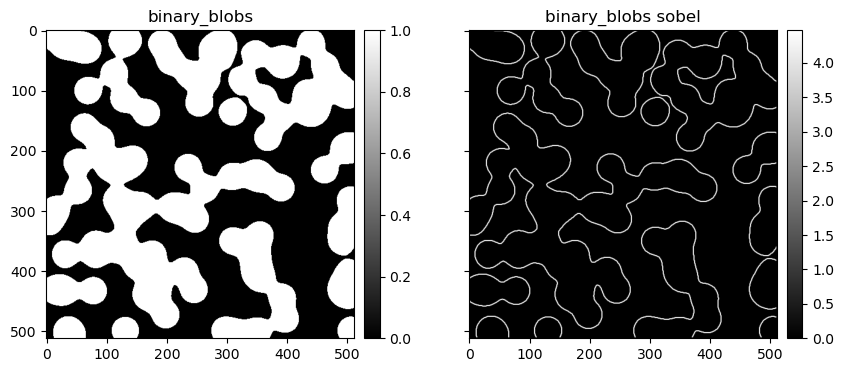

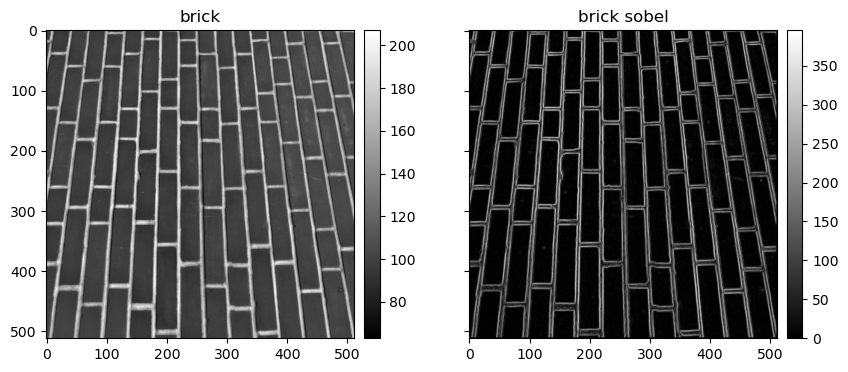

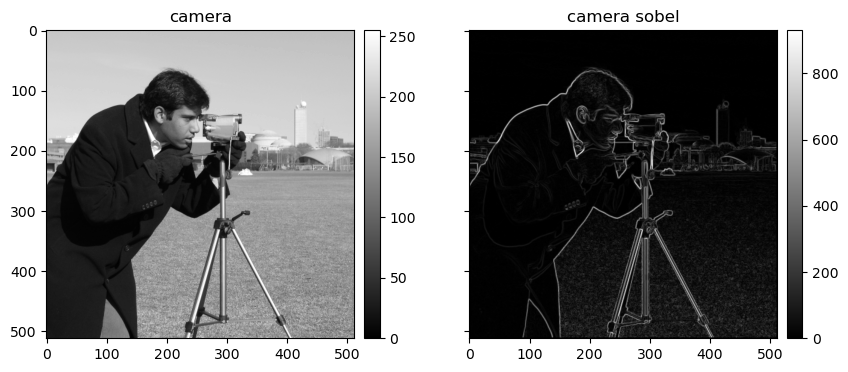

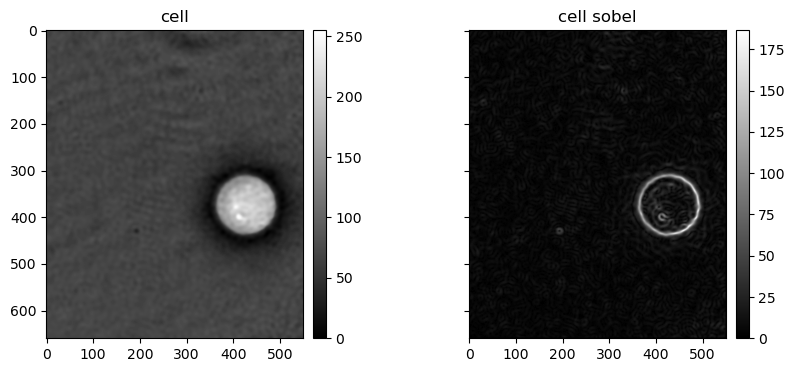

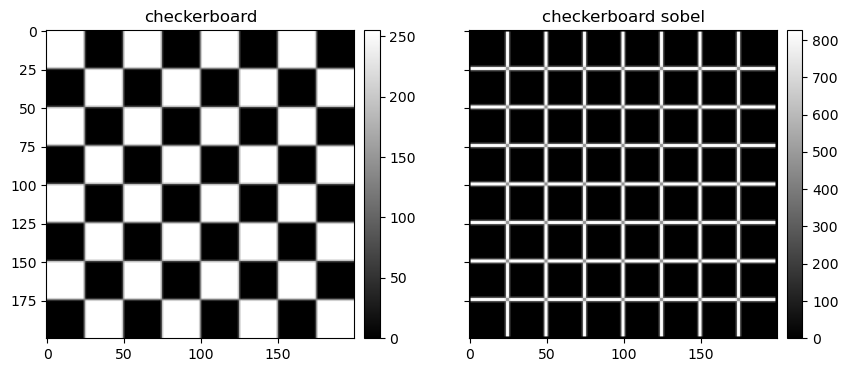

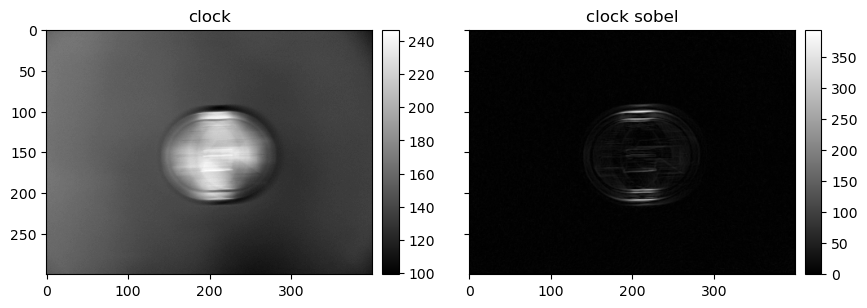

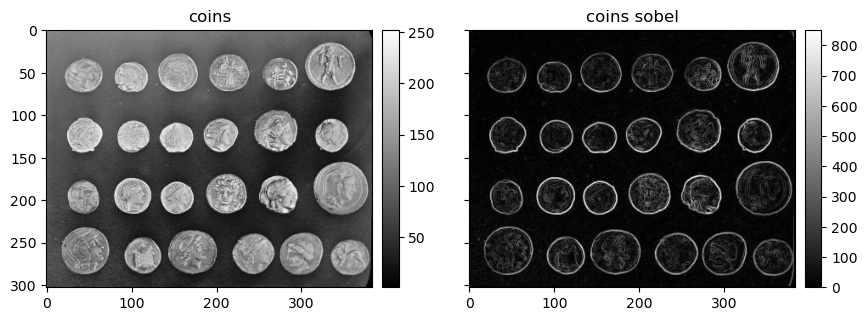

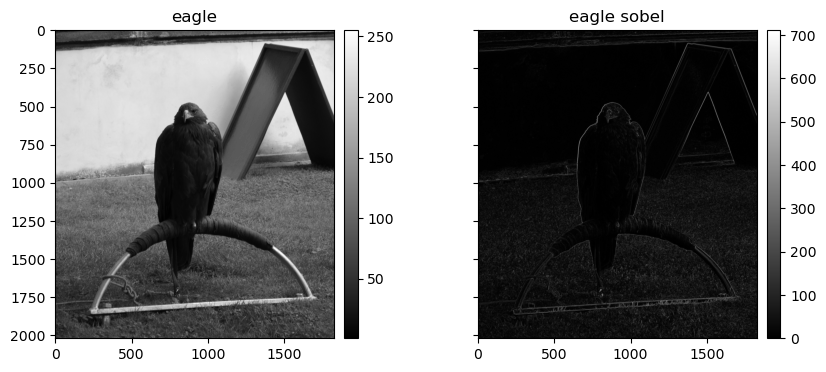

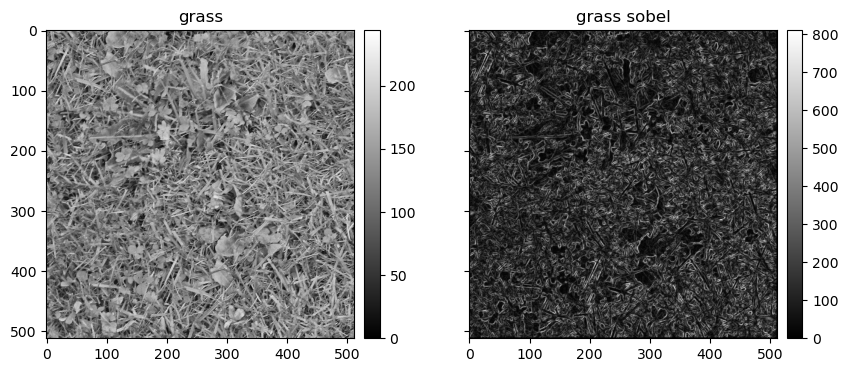

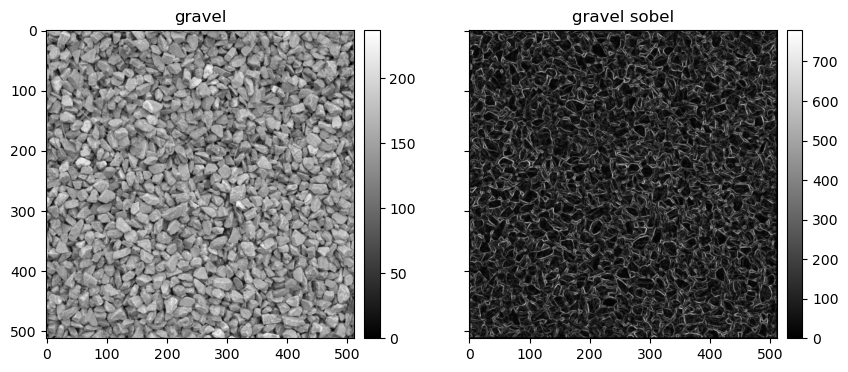

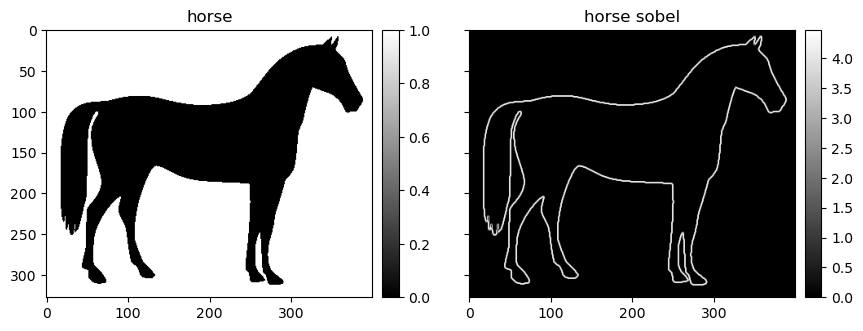

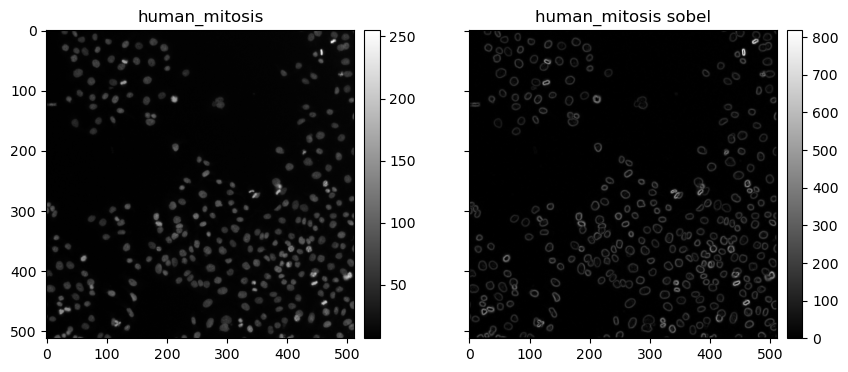

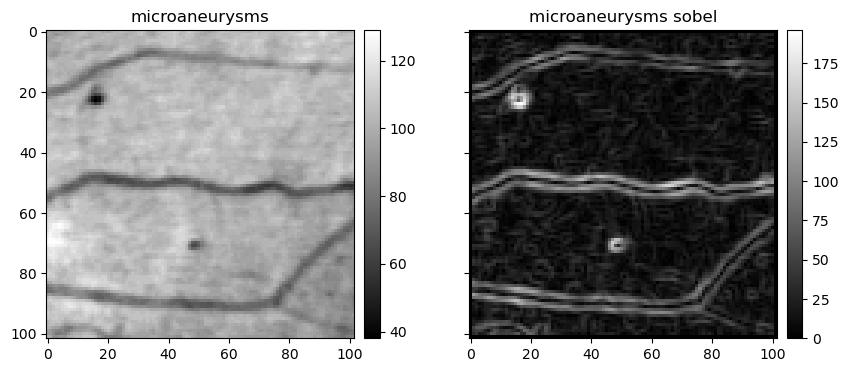

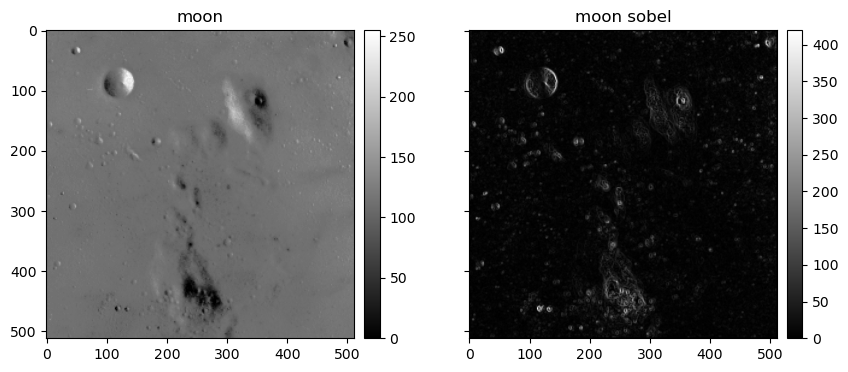

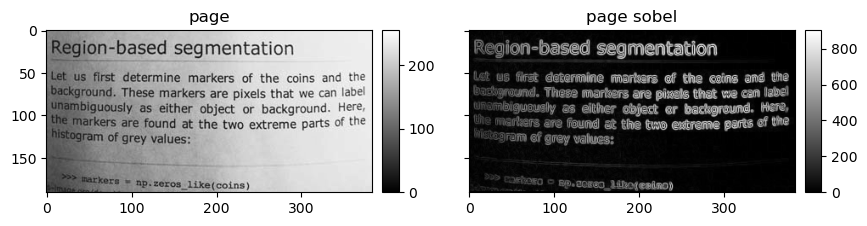

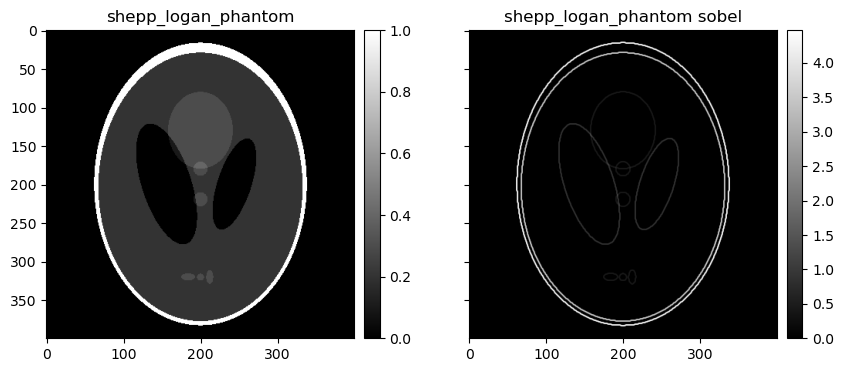

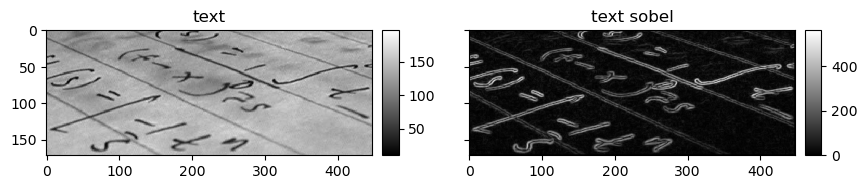

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


def create_colorbar(im, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cb = ax.get_figure().colorbar(im, cax=cax, orientation="vertical")
    return cax, cb


for name, data in bwimages.items():
    fig, axs = plt.subplots(
        1, 2, figsize=(10, 4), sharex=True, sharey=True
    )
    im = axs[0].imshow(data, aspect="equal", cmap="gray")
    create_colorbar(im, axs[0])
    axs[0].set(title=name)

    im = axs[1].imshow(bwimages_sobel[name], aspect="equal", cmap="gray")
    create_colorbar(im, axs[1])
    axs[1].set(title=f"{name} sobel")